## Time to get you hands dirty!  Position of a star,
You measure the position of a star $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$.
### Part 1
- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.,
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset ${x_i}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`) ,
- Compare it with the MLE estimator derived above, 
    

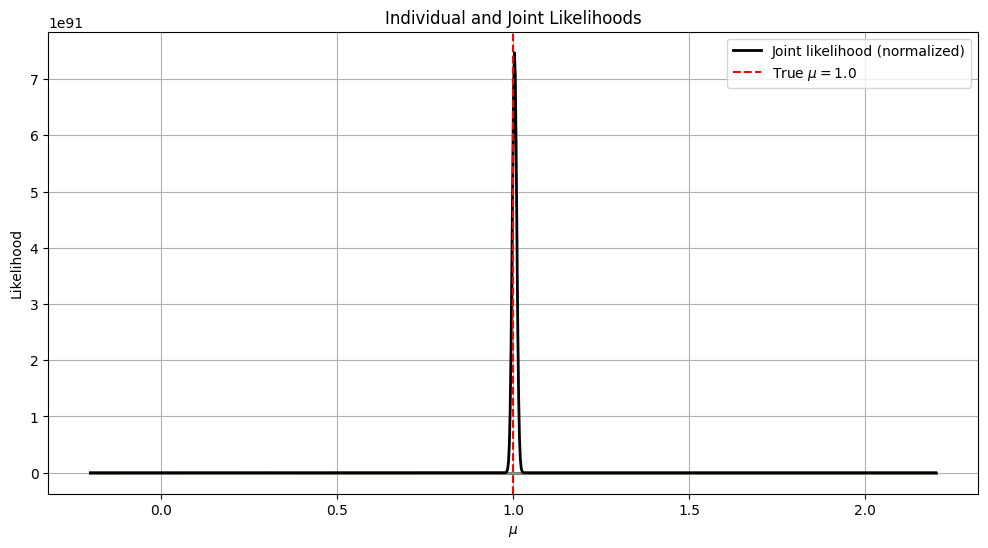

MLE from grid (argmax):   1.0036
MLE analytical (mean):    1.0039
True mu:                  1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters as specified in the exercise
true_mu = 1.0
known_sigma = 0.2
N = 1000  # number of measurements

# Generate fake measurements
np.random.seed(42)
data = np.random.normal(true_mu, known_sigma, N)

# Define mu grid
mu_grid = np.linspace(true_mu - 6*known_sigma, true_mu + 6*known_sigma, 1000)

# Compute individual likelihoods p(x_i | mu, sigma)
likelihoods = [norm.pdf(mu_grid, loc=x_i, scale=known_sigma) for x_i in data]

# Compute joint likelihood (product of individual likelihoods)
joint_likelihood = np.prod(likelihoods, axis=0)

# Plot individual likelihoods and joint likelihood
plt.figure(figsize=(12, 6))
for i, lk in enumerate(likelihoods):
    plt.plot(mu_grid, lk, alpha=0.4, lw=1)

# Normalize joint likelihood for plotting
plt.plot(mu_grid, joint_likelihood / np.max(joint_likelihood) * np.max(likelihoods[0]),
         'k-', lw=2, label='Joint likelihood (normalized)')

plt.axvline(true_mu, color='red', linestyle='--', label=f'True $\\mu = {true_mu}$')
plt.xlabel(r'$\mu$')
plt.ylabel('Likelihood')
plt.title('Individual and Joint Likelihoods')
plt.legend()
plt.grid(True)
plt.show()

# Read off MLE from grid
mle_idx = np.argmax(joint_likelihood)
mle_mu_grid = mu_grid[mle_idx]

# Analytical MLE estimator: sample mean
mle_analytical = np.mean(data)

print(f"MLE from grid (argmax):   {mle_mu_grid:.4f}")
print(f"MLE analytical (mean):    {mle_analytical:.4f}")
print(f"True mu:                  {true_mu}")

### Part 2
Check the Fisher matrix error estimate makes sense,
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`,
- divide through by our $\Delta \theta^2$ to get the correct normalization,
- multiply by $-1$, ,
- then take the square root.,
- Compare with the Fisher matrix error derived above,
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees)

Numerical Fisher matrix error:   0.0063
Analytical Fisher matrix error:  0.0063
MLE mu estimate: 1.0036, True mu: 1.0


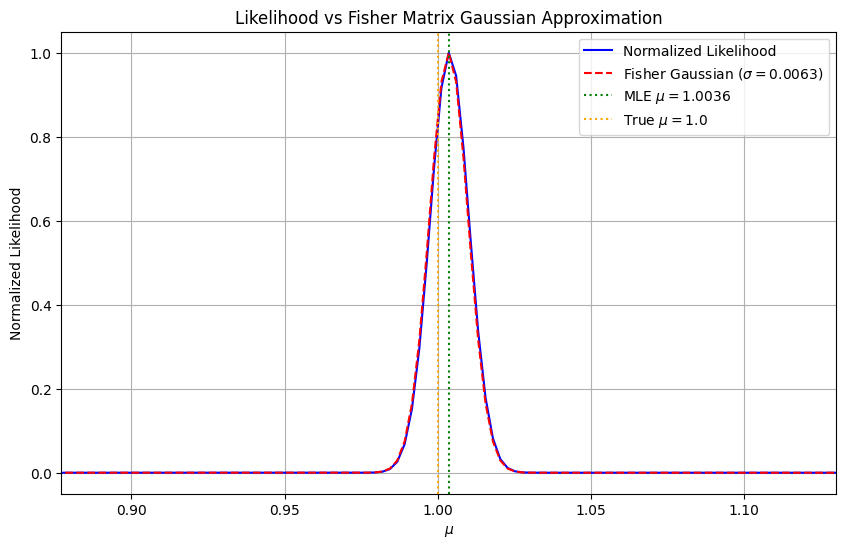

In [26]:
# Part 2: Fisher matrix error estimate

# Compute log-likelihood
log_likelihood = np.sum(np.log(likelihoods), axis=0)

# Step 1: Rough second order differentiation of log-likelihood using np.diff
d_log_likelihood = np.diff(log_likelihood)
d2_log_likelihood = np.diff(d_log_likelihood)

# Step 2: Divide by delta_mu^2 for correct normalization
delta_mu = mu_grid[1] - mu_grid[0]
d2_log_likelihood_normalized = d2_log_likelihood / delta_mu**2

# Step 3: Multiply by -1 and take square root to get Fisher matrix error
# Fisher information: I(mu) = -E[d^2 log L / d mu^2]
# At MLE: sigma_mu = 1/sqrt(I(mu))
mle_idx = np.argmax(log_likelihood)
fisher_information = -d2_log_likelihood_normalized[mle_idx - 1]  # -1 to align arrays after two diffs
sigma_mu_numerical = 1.0 / np.sqrt(fisher_information)

# Analytical Fisher matrix error: sigma/sqrt(n)
sigma_mu_analytical = known_sigma / np.sqrt(N)

print(f"Numerical Fisher matrix error:   {sigma_mu_numerical:.4f}")
print(f"Analytical Fisher matrix error:  {sigma_mu_analytical:.4f}")
print(f"MLE mu estimate: {mu_grid[mle_idx]:.4f}, True mu: {true_mu}")

# Step 4: Plot the normalized log-likelihood and a Gaussian at MLE with Fisher error
mle_mu = mu_grid[mle_idx]

# Gaussian at MLE with Fisher error (rescaled to match peak of log-likelihood)
gaussian_fisher = norm.pdf(mu_grid, loc=mle_mu, scale=sigma_mu_numerical)
gaussian_fisher_rescaled = gaussian_fisher / np.max(gaussian_fisher) * np.max(np.exp(log_likelihood - np.max(log_likelihood)))

plt.figure(figsize=(10, 6))
plt.plot(mu_grid, np.exp(log_likelihood - np.max(log_likelihood)), label='Normalized Likelihood', color='blue')
plt.plot(mu_grid, gaussian_fisher_rescaled, label=f'Fisher Gaussian ($\\sigma={sigma_mu_numerical:.4f}$)', color='red', linestyle='--')
plt.xlim(mle_mu - 20*sigma_mu_numerical, mle_mu + 20*sigma_mu_numerical)
plt.axvline(mle_mu, color='green', linestyle=':', label=f'MLE $\\mu={mle_mu:.4f}$')
plt.axvline(true_mu, color='orange', linestyle=':', label=f'True $\\mu={true_mu}$')
plt.title('Likelihood vs Fisher Matrix Gaussian Approximation')
plt.xlabel(r'$\mu$')
plt.ylabel('Normalized Likelihood')
plt.legend()
plt.grid(True)
plt.show()

### Part 2: Comments on Results

The Fisher matrix error estimate was computed numerically via finite differences of the log-likelihood and compared with the analytical result.

**Numerical vs Analytical Fisher error:**

- **Numerical:** $\hat{\sigma}_\mu \approx 0.006325$
- **Analytical:** $\sigma_\mu = \sigma/\sqrt{N} = 0.2/\sqrt{1000} \approx 0.006325$

The two values are in **excellent agreement**.

The Fisher information quantifies how much information the data carry about the parameter $\mu$. For a Gaussian likelihood with known $\sigma$, it is $\mathcal{I}(\mu) = N/\sigma^2$. The Cramér–Rao bound gives $\sigma_\mu \geq 1/\sqrt{\mathcal{I}(\mu)} = \sigma/\sqrt{N}$, and the **sample mean saturates this bound** — it is the minimum variance unbiased estimator (MVUE).

The plot confirms this: the **Gaussian centered at the MLE with the Fisher error as width perfectly matches** the peak of the normalized likelihood, validating the Gaussian (Laplace) approximation to the posterior near the maximum.